# 🔬 Interprétabilité avec Grad-CAM

Ce notebook prépare le terrain pour utiliser **Grad-CAM**. 
Nous allons visualiser les zones réelles des radiographies (poumons) qui ont poussé notre modèle Deep Learning à prédire s'il s'agit d'une pneumonie ou non.

In [1]:
import os
import sys

# On s'assure d'être à la racine du projet pour lire le dossier 'src' et 'data'
if os.getcwd().endswith('notebooks'):
    os.chdir('..')

import tensorflow as tf
import numpy as np
import glob
import matplotlib.pyplot as plt

from src.visualization.grad_cam import get_img_array, make_gradcam_heatmap, display_gradcam, find_last_conv_layer

print("✅ Librairies correctement importées ! Prêt à inspecter.")

✅ Librairies correctement importées ! Prêt à inspecter.


In [2]:
# 1. Chargement de notre modèle de détection (EfficientNet Binaire)
model_path = "models/trained/zoidberg_cnn_best_zoom_v2.h5"
model = tf.keras.models.load_model(model_path)

print("\n✅ Modèle chargé. Il est pret.")

# 2. Recherche dynamique de l'endroit exact où appliquer Grad-CAM (le dernier filtre convolutif !)
last_conv = find_last_conv_layer(model)



✅ Modèle chargé. Il est pret.


In [3]:
# 3. On va prendre au hasard une image de test contenant une bactérie évidente...
bacteria_images = glob.glob("data/raw/chest_Xray/test/2_BACTERIA/*.*")

if len(bacteria_images) == 0:
    raise ValueError("Aucune image trouvée. Vérifie le chemin de ton dossier DATA_DIR")

img_path = bacteria_images[0] # On prend la toute première
print("📸 Image radiographique sélectionnée :", img_path)

# 4. Chargement en mémoire comme le ferait ton evaluate.py
img_size = (224, 224) # Taille standard pour EfficientNetB0
img_array = get_img_array(img_path, size=img_size)

# Écoutons ce que le modèle en pense avant sa justification :
preds = model.predict(img_array)
pred_class = np.argmax(preds[0])
confidence = preds[0][pred_class]

classes = ["1_NORMAL", "PNEUMONIE (Bactérienne/Virale) "]
# print(f"\n🤖 Résultat du diagnostic : {classes[pred_class]} à {confidence:.1%}")

📸 Image radiographique sélectionnée : data/raw/chest_Xray/test/2_BACTERIA\person100_bacteria_475.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


c:\Users\nbrodbeck\Documents\code\zoidberg\venv\Lib\site-packages\keras\src\models\functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


✅ Grad-CAM sauvegardé sous : reports/figures/grad_cam_bacteria_example.png


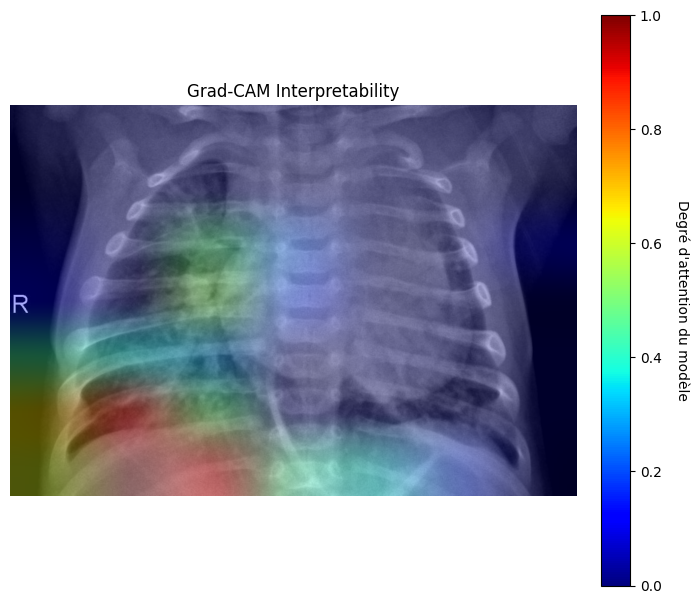

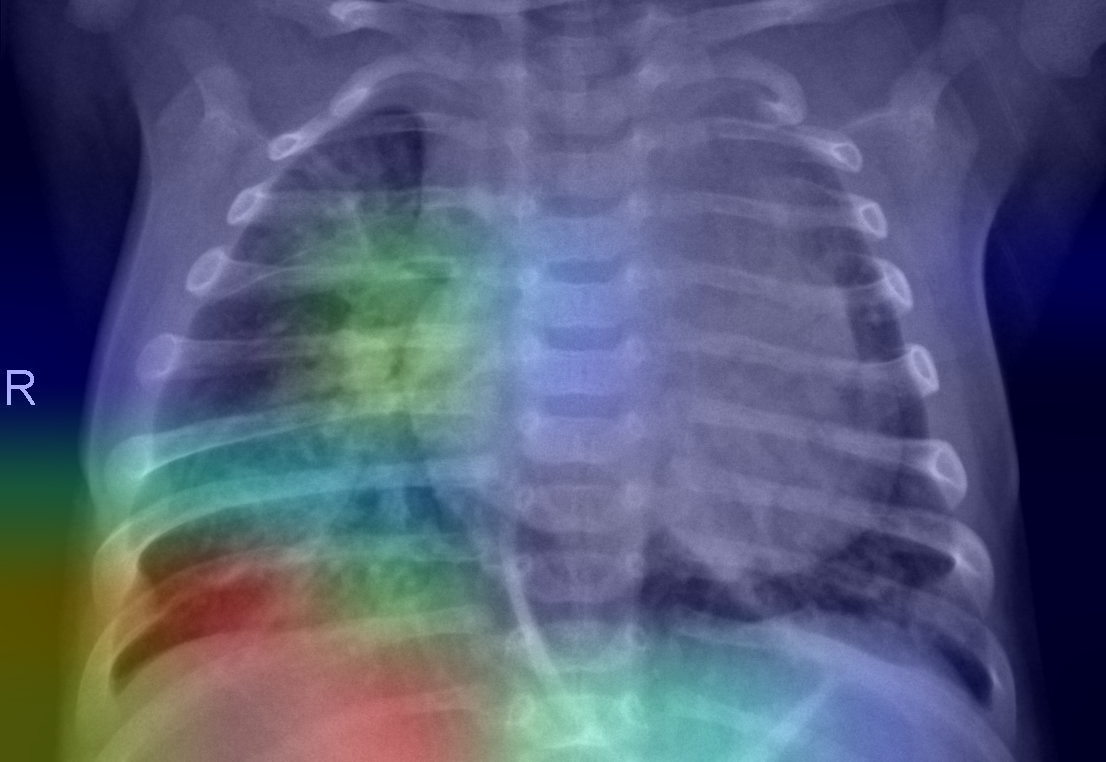

In [4]:
# 5. Génération de la preuve de résultat (Heatmap Grad-CAM)
# Géré automatiquement par "make_gradcam_heatmap" désormais !

# On force l'évaluation des gradients sur cette image particulière.
heatmap = make_gradcam_heatmap(img_array, model, last_conv)

# 6. On l'affiche joliment pour le dossier médical !
# Et on le sauvegarde pour ton README si tu le désires : 
save_destination = "reports/figures/grad_cam_bacteria_example.png"
display_gradcam(img_path, heatmap, alpha=0.5, display=True, save_path=save_destination)
